# Test2 --- individual NLE 
This time we also condition on measured uncertainty: $p(X|\phi,\sigma)$ 

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [5]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [4]:
params = np.load('/Users/chang/data/px2cosmo/test2/mock2_N50000subsamp100.params.npy')
data = np.load('/Users/chang/data/px2cosmo/test2/mock2_N50000subsamp100.data.npy')

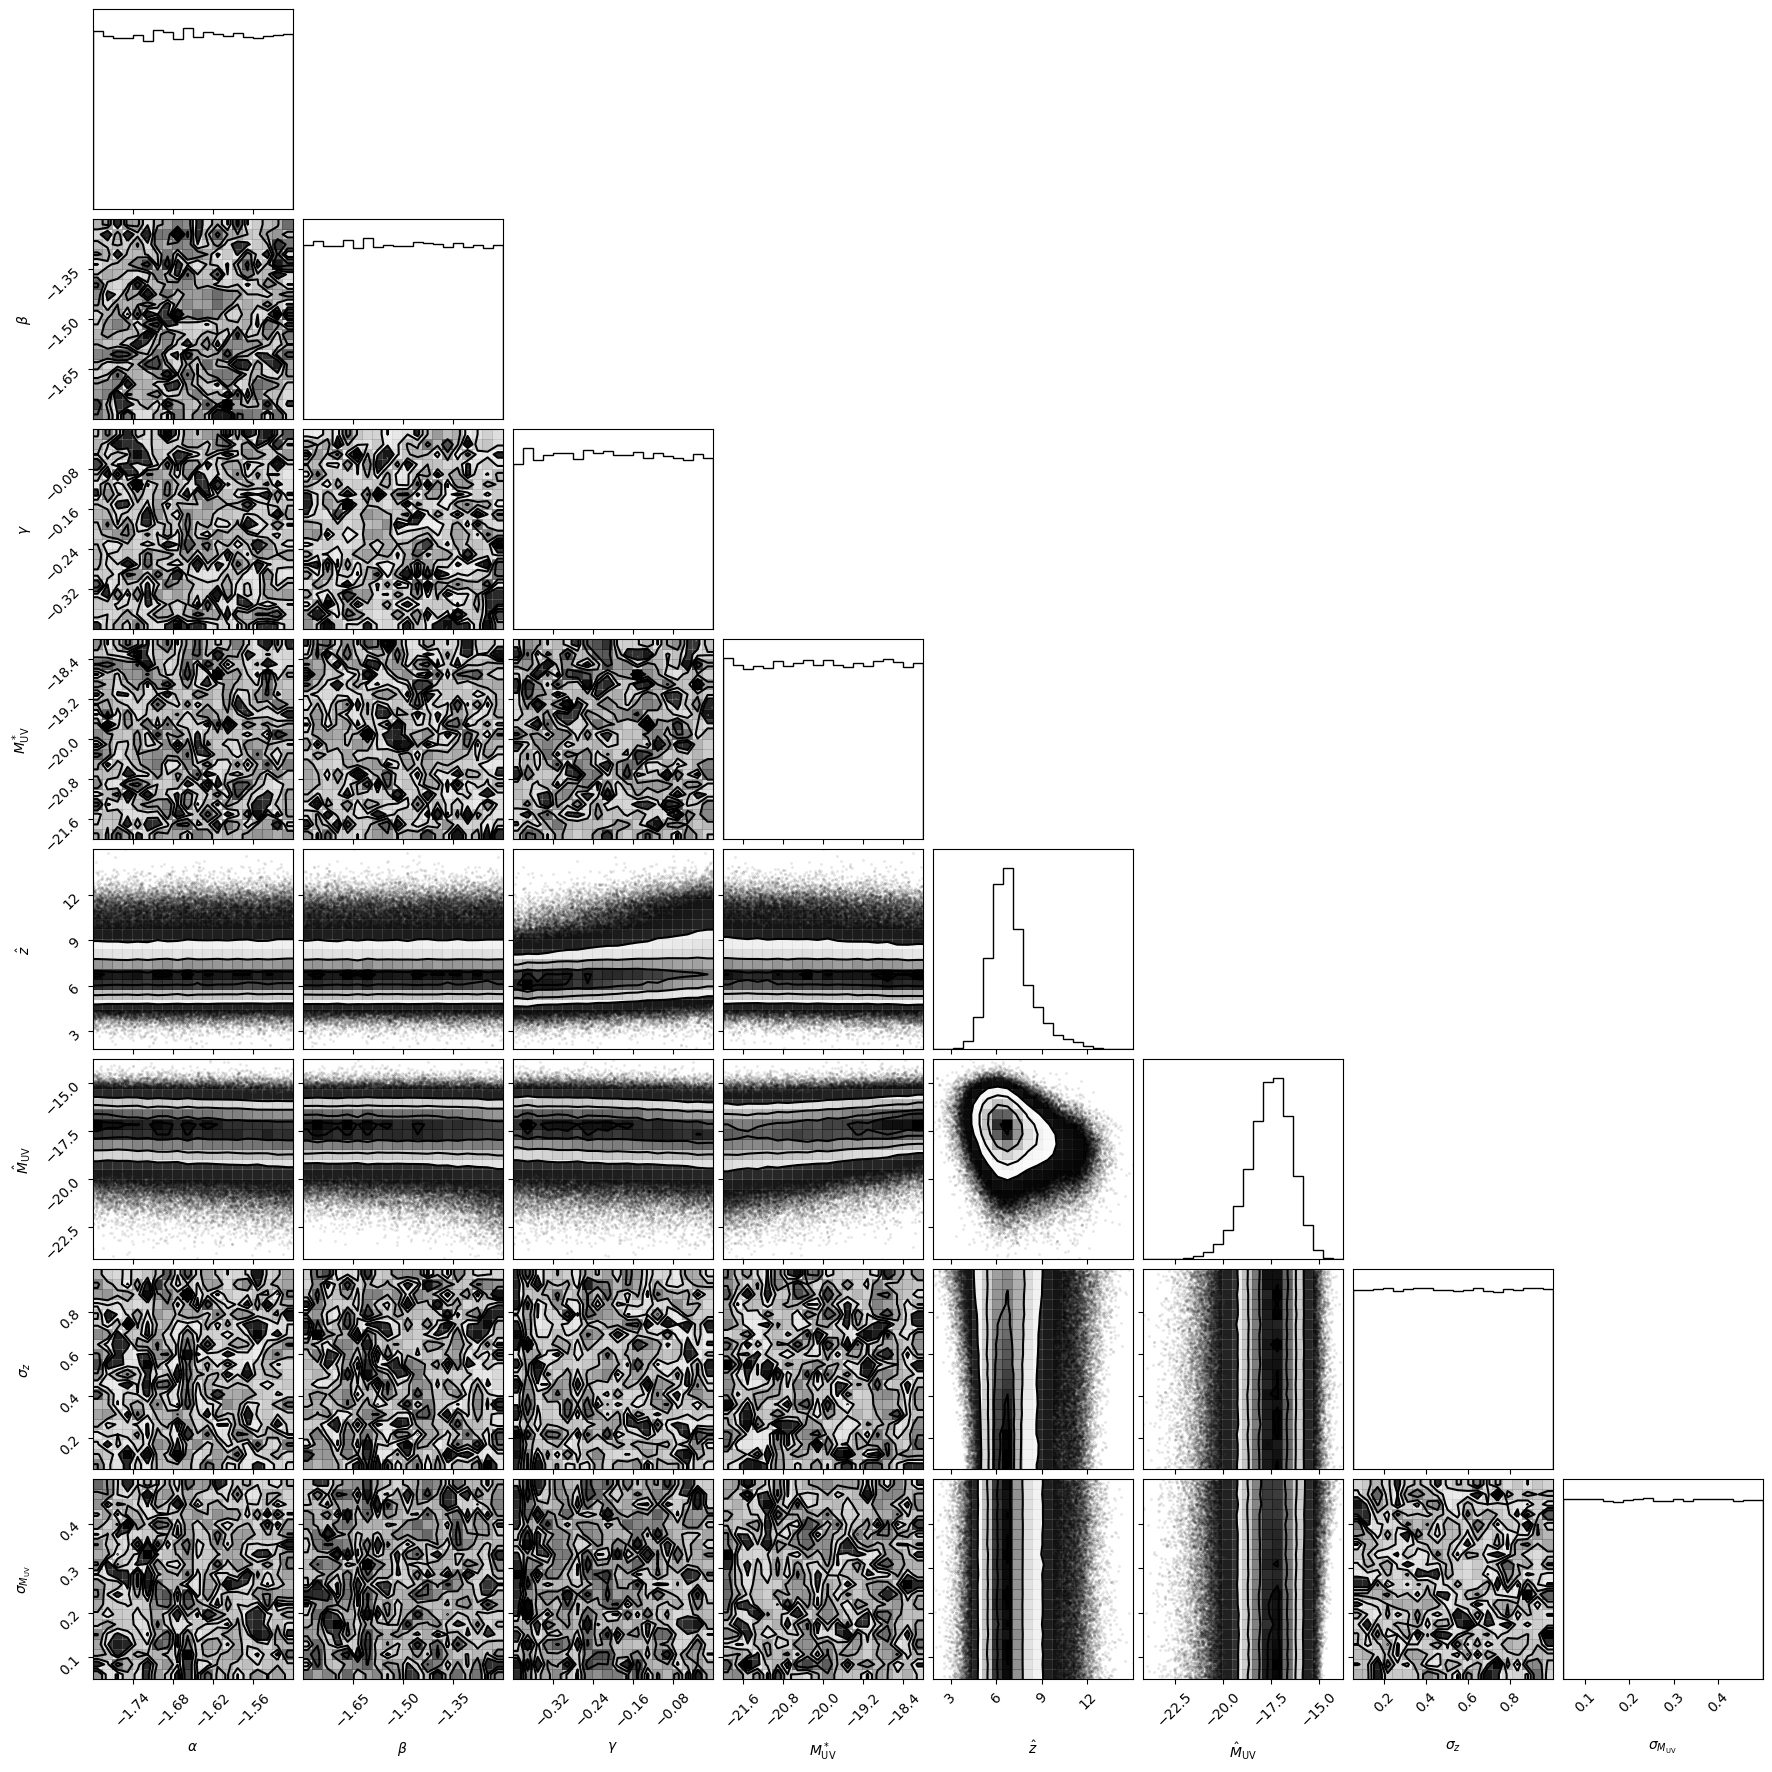

In [6]:
fig = DFM.corner(np.hstack([params, data])[::10], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', 
                         r'$\hat{z}$', r'$\hat{M}_{\rm UV}$', 
                         r'$\sigma_{z}$', r'$\sigma_{{M}_{\rm UV}}$'])

## train NDE
We want to estimate $p(X\,|\,\phi,\sigma)$

In [7]:
ishuffle = np.arange(params.shape[0])
np.random.shuffle(ishuffle)

In [8]:
X = data[:,:2]
sig = data[:,2:]
phi = params

In [9]:
_phi = torch.tensor(np.hstack([phi, sig])[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')
_X = torch.tensor(X[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')

In [10]:
inference = NPE(density_estimator='zuko_maf')#, device='mps')
_ = inference.append_simulations(_X, _phi).train()

 Neural network successfully converged after 61 epochs.

In [11]:
p_X_phisig = inference.build_posterior()

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


## validate NDE

In [12]:
test_phi = torch.tensor(np.hstack([phi, sig])[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')
test_X = torch.tensor(X[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')

  0%|          | 0/10000 [00:00<?, ?it/s]

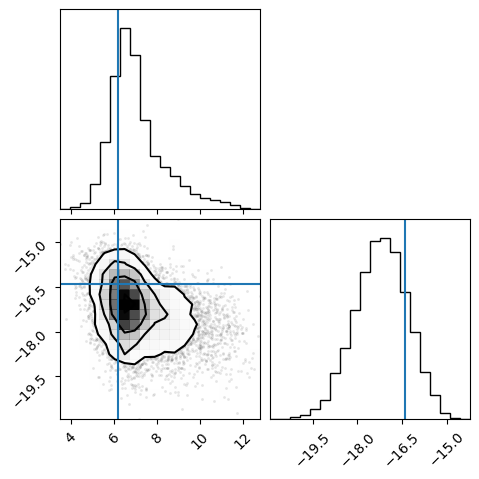

  0%|          | 0/10000 [00:00<?, ?it/s]

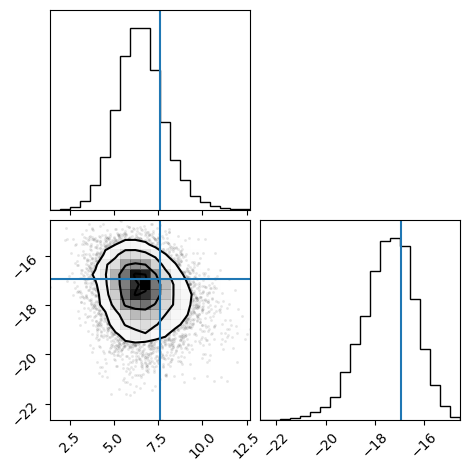

  0%|          | 0/10000 [00:00<?, ?it/s]

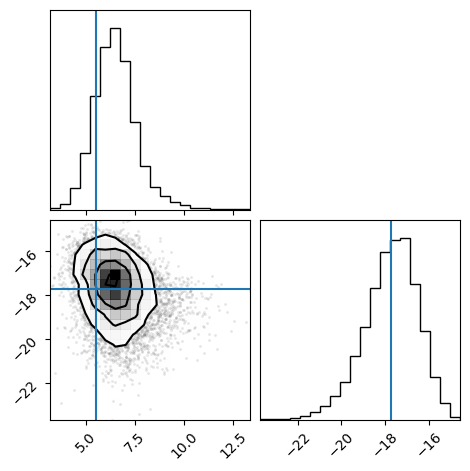

In [13]:
for i in range(3):
    samples = p_X_phisig.sample((10000,), x=test_phi[i]).cpu()
    fig = DFM.corner(samples.numpy())
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [14]:
test_samples = p_X_phisig.sample_batched((1000,), x=test_phi, norm_posterior=False, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_7809/1803342371.py:1: UserWarning: Note that for batched sampling, the direct posterior sampling generates 50000 * 1000 = 50000000 samples. This can be slow and memory-intensive. Consider reducing the number of samples or batch size.
  test_samples = p_X_phisig.sample_batched((1000,), x=test_phi, show_progress_bars=False)
/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_7809/1803342371.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 2 to avoid excessive memory usage.
  test_samples = p_X_phisig.sample_batched((1000,), x=test_phi, show_progress_bars=False)


In [15]:
import tarp

In [16]:
ecp, alpha = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X.cpu().numpy())

Text(0.5, 0, 'Credibility Level')

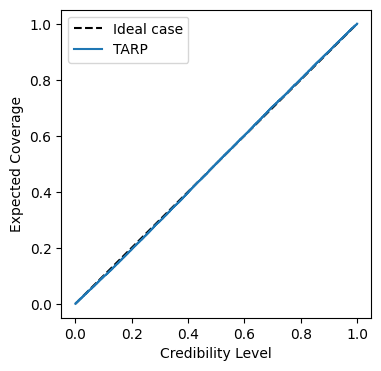

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

# additional tests of the likelihood
comparison directly against forward model

  0%|          | 0/10000 [00:00<?, ?it/s]

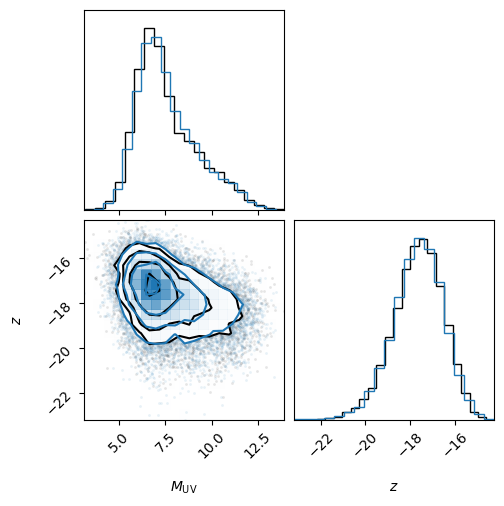

  0%|          | 0/10000 [00:00<?, ?it/s]

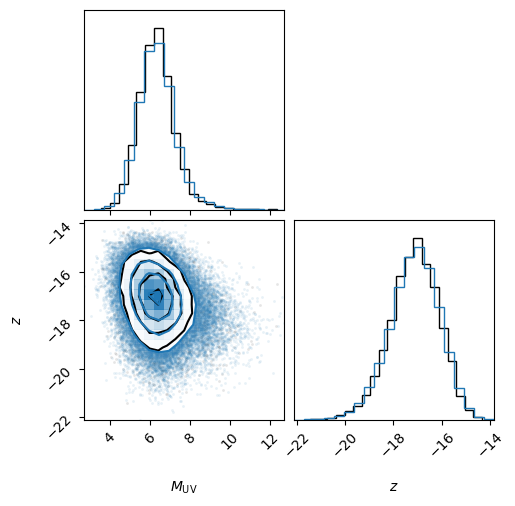

  0%|          | 0/10000 [00:00<?, ?it/s]

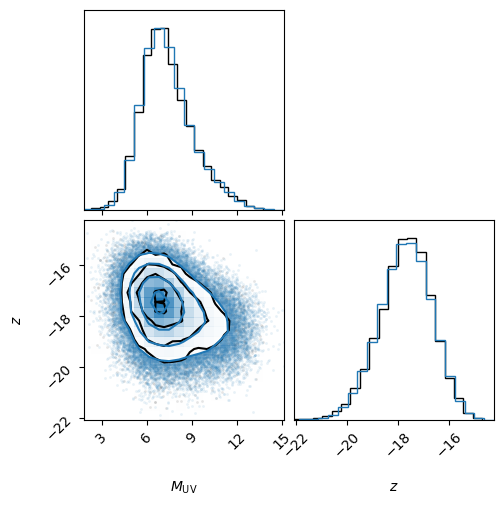

  0%|          | 0/10000 [00:00<?, ?it/s]

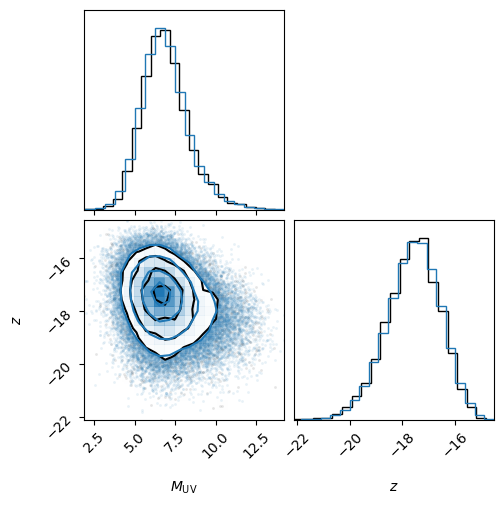

  0%|          | 0/10000 [00:00<?, ?it/s]

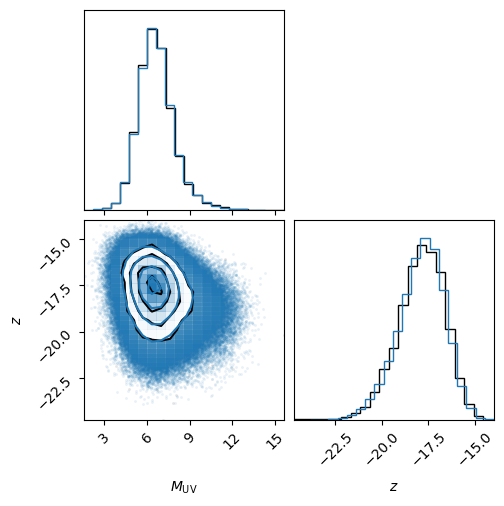

  0%|          | 0/10000 [00:00<?, ?it/s]

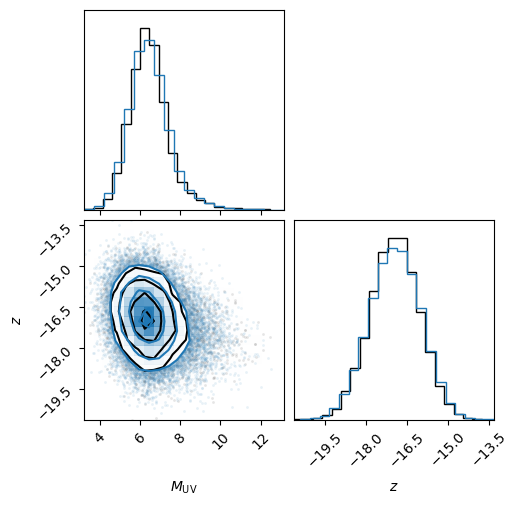

  0%|          | 0/10000 [00:00<?, ?it/s]

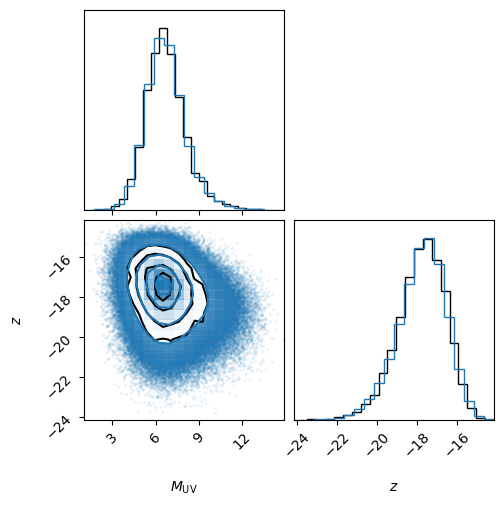

  0%|          | 0/10000 [00:00<?, ?it/s]

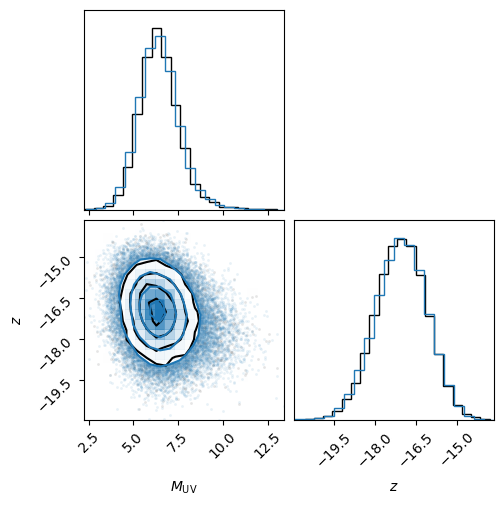

  0%|          | 0/10000 [00:00<?, ?it/s]

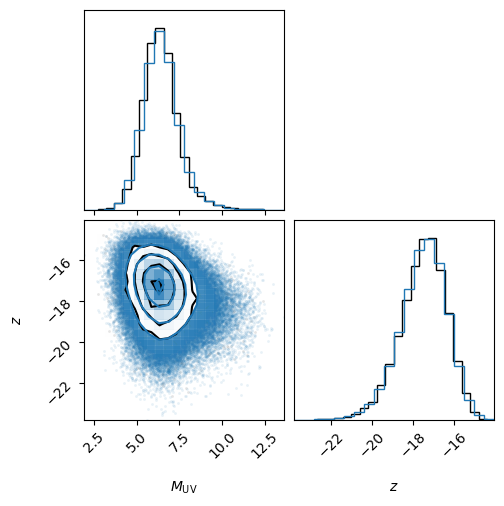

  0%|          | 0/10000 [00:00<?, ?it/s]

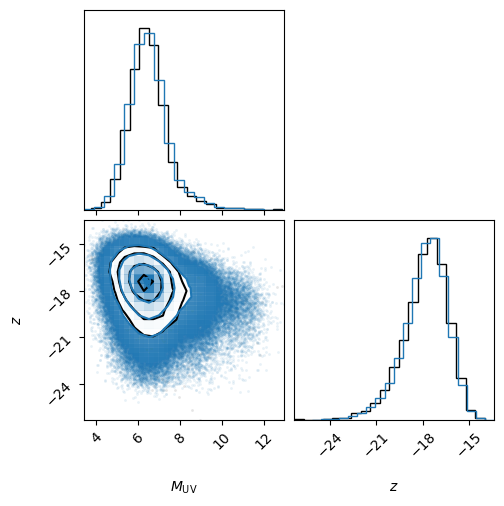

In [20]:
for i in range(10): 
    _alpha = np.random.uniform(-1.8, -1.5) 
    _beta = np.random.uniform(-1.8, -1.2)
    _gamma = np.random.uniform(-0.4, 0.0) 
    _Muv_s = np.random.uniform(-22., -18.)
    _phi = np.array([_alpha, _beta, _gamma, _Muv_s])

    _sig_z = np.random.uniform(0.1, 1)
    _sig_Muv = np.random.uniform(0.1, 0.5)

    _Xs = [] 
    for _ in range(10): 
        _X = FM.forwardmodel(_phi, name='test1')
        _X[:,0] += _sig_z * np.random.normal(size=_X.shape[0])
        _X[:,1] += _sig_Muv * np.random.normal(size=_X.shape[0])
        _Xs.append(_X)
    
    _phi = np.array([_alpha, _beta, _gamma, _Muv_s, _sig_z, _sig_Muv])
    samples = p_X_phisig.sample((10000,), x=torch.tensor(_phi.astype(np.float32))).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={'density':True})
    _ = DFM.corner(np.vstack(_Xs), labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={'density':True})
    plt.show()

In [22]:
phi_true = np.array([-1.65, -1.5, -0.2, -19.5]) # fit by eye to zeus21 output

# sample LF 
X_obs = FM.forwardmodel(phi_true, name='test2')

In [23]:
_X_obs = torch.tensor(X_obs[:,:2].astype(np.float32)) #.to('mps')
_X_obs_sig = torch.tensor(X_obs[:,2:].astype(np.float32))
_logN_obs = torch.tensor(np.log(X_obs.shape[0]).astype(np.float32))

In [24]:
def log_posterior(phi, silent=True):         
    _phi = torch.tensor(phi.astype(np.float32))
    # log likelihood
    _phisig = torch.cat([_phi.expand(X_obs.shape[0], -1), _X_obs_sig], dim=1)
    logp = p_X_phisig.log_prob_batched(_X_obs, _phisig, norm_posterior=False).sum().item()        
    return logp

In [29]:
# 1D slice through alpha, fixing everything else at phi_true
alphas = np.linspace(-1.8, -1.5, 30)
lp_slice = []
for a in alphas:
    phi = np.array([a, phi_true[1], phi_true[2], phi_true[3]])
    lp_slice.append(log_posterior(phi))

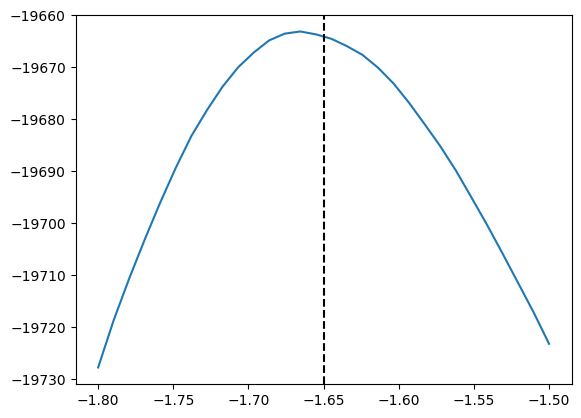

In [30]:
plt.plot(alphas, lp_slice)
plt.axvline(phi_true[0], c='k', ls='--')

In [26]:
# 1D slice through alpha, fixing everything else at phi_true
betas = np.linspace(-1.8, -1.2, 30)
lp_slice = []
for b in betas:
    phi = np.array([phi_true[0], b, phi_true[2], phi_true[3]])
    lp_slice.append(log_posterior(phi))

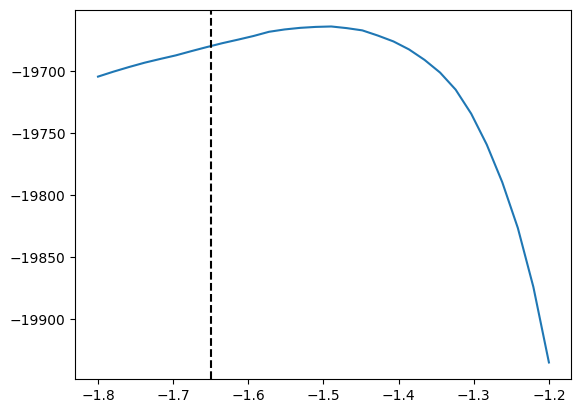

In [28]:
plt.plot(betas, lp_slice)
plt.axvline(phi_true[0], c='k', ls='--')

In [21]:
torch.save(p_X_phisig, '/Users/chang/data/px2cosmo/test2/mock2_p_X_phisig.pt')